In [ ]:
from aicsimageio import AICSImage
import numpy as np

img = AICSImage("your_image.ome.tif")
z_stack = img.data[0, 0]  # shape: (Z=23, Y=20739, X=28492)
z_stack = z_stack.astype(np.float32)
z_stack = (z_stack - z_stack.min()) / (z_stack.max() - z_stack.min() + 1e-8)

In [1]:
import numpy as np
import os
from PIL import Image
from skimage.exposure import rescale_intensity
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes, disk, dilation
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import watershed
from skimage.measure import regionprops
import pandas as pd

# Increase max image pixels to something very high
Image.MAX_IMAGE_PIXELS = None

In [2]:
# Load data image and centroids
img = np.array(Image.open("../../data/png_images/TgCRND8_2_5_morphology_mip.png").convert("L")).astype(float)
data = pd.read_csv("../../data/preprocessed_data/10xgenomics_alzheimers_disease_mouse_data.csv")

In [3]:
img.shape

(20739, 28492)

In [ ]:
# Preprocess data
centroids = data[['coord_X', 'coord_Y']].to_numpy()

# get the min and max of the centroids x and y coordinates
max_x = centroids[:, 0].max()
max_y = centroids[:, 1].max()

# centroids = centroids[:5]

image = rescale_intensity(img, in_range='image', out_range=(0, 1))
image_smooth = gaussian(image, sigma=1)

# Binary Mask
thresh = threshold_otsu(image_smooth)
binary = image_smooth > thresh
binary = remove_small_objects(binary, min_size=20)
binary = remove_small_holes(binary, area_threshold=20)
binary = dilation(binary, disk(3))

# Create Markers for Watershed
markers = np.zeros_like(image, dtype=int)
label_to_centroid = {}

for i, (x, y) in enumerate(centroids):
    # convert x, y to pixel coordinates
    x = int(x / .2125)
    y = int(y / .2125)
    # print(f"Centroid {i}: ({x}, {y})")
    if 0 <= y < markers.shape[0] and 0 <= x < markers.shape[1]:
        label_id = i + 1
        markers[y, x] = label_id
        label_to_centroid[label_id] = (x, y)

# Watershed 
distance = distance_transform_edt(binary)
labels = watershed(-distance, markers, mask=binary)

# Extract and Save Cells as PNGs
from skimage.util import img_as_ubyte
import pandas as pd

props = regionprops(labels, intensity_image=image)
output_dir = "cells_png_output"
os.makedirs(output_dir, exist_ok=True)

output_data = []

for i, region in enumerate(props):
    label_id = region.label
    if label_id not in label_to_centroid or region.area < 20:
        continue

    centroid = label_to_centroid[label_id]
    minr, minc, maxr, maxc = region.bbox

    cell_crop = image[minr:maxr, minc:maxc]
    mask_crop = region.image
    cell_morph = cell_crop * mask_crop

    # Convert to uint8 PNG
    cell_morph_rescaled = rescale_intensity(cell_morph, in_range='image', out_range=(0, 255)).astype(np.uint8)
    filename = f"cell_{i:04d}.png"
    Image.fromarray(cell_morph_rescaled).save(os.path.join(output_dir, filename))

    # Metadata
    output_data.append({
        "filename": filename,
        "centroid_x": centroid[0],
        "centroid_y": centroid[1],
        "label": label_id,
        "bbox": region.bbox,
        "area": region.area
    })

# ========== Save CSV ==========
df = pd.DataFrame(output_data)
df.to_csv("cell_morphology_centroid_mapping.csv", index=False)

print(f"✅ Saved {len(output_data)} cell PNGs to '{output_dir}/'")

✅ Saved 29398 cell PNGs to 'cells_png_output/'


In [33]:
# Preprocess data
centroids = data[['coord_X', 'coord_Y']].to_numpy()

# get the min and max of the centroids x and y coordinates
max_x = centroids[:, 0].max()
max_y = centroids[:, 1].max()

print(f"Max X: {max_x}, Max Y: {max_y}")

centroids = centroids[:20]

Max X: 6656.921508789063, Max Y: 5276.820336914062


Showing image patch at (843.6882415771485, 608.2981628417969)
Patch coordinates: (3920, 2812) to (4020, 2912)


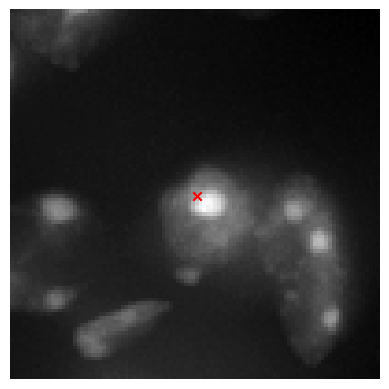

Showing image patch at (851.0892700195312, 612.5555297851562)
Patch coordinates: (3955, 2832) to (4055, 2932)


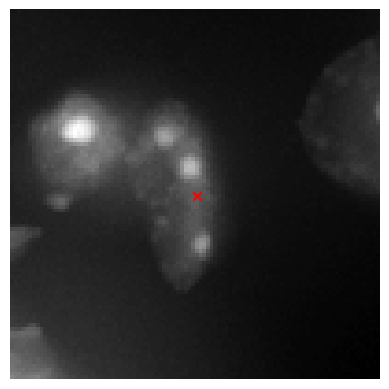

Showing image patch at (833.5573455810546, 611.5013305664062)
Patch coordinates: (3872, 2827) to (3972, 2927)


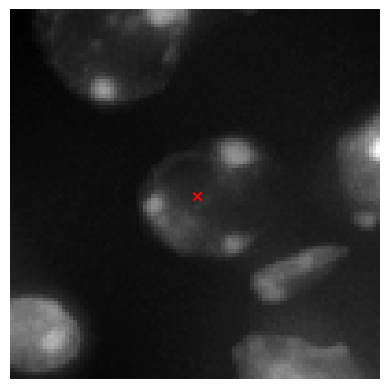

Showing image patch at (840.1113311767577, 616.1445281982421)
Patch coordinates: (3903, 2849) to (4003, 2949)


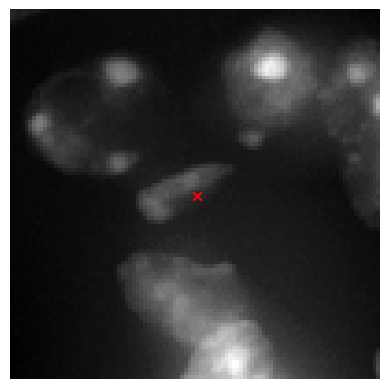

Showing image patch at (824.7092834472656, 622.8941009521484)
Patch coordinates: (3830, 2881) to (3930, 2981)


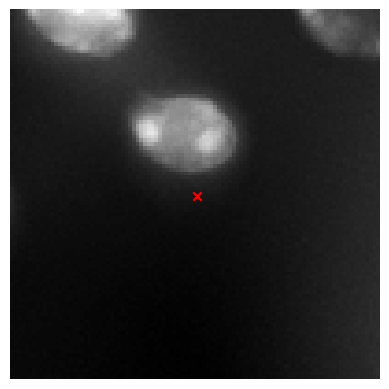

Showing image patch at (837.3404266357421, 621.9748413085937)
Patch coordinates: (3890, 2876) to (3990, 2976)


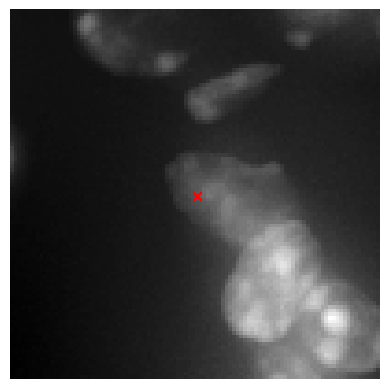

Showing image patch at (838.1181579589844, 627.928109741211)
Patch coordinates: (3894, 2904) to (3994, 3004)


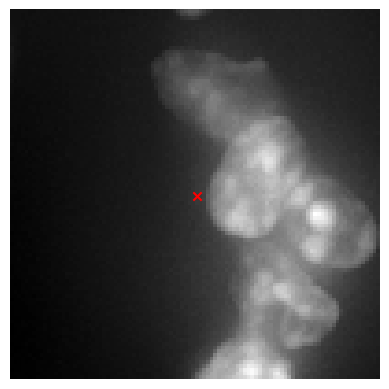

Showing image patch at (847.8789428710937, 630.4812225341797)
Patch coordinates: (3940, 2916) to (4040, 3016)


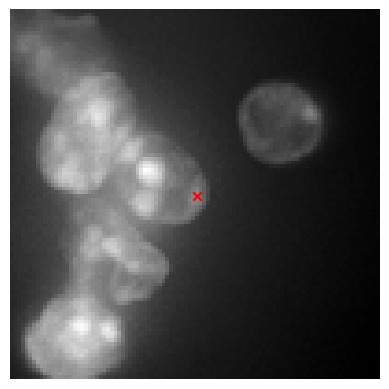

Showing image patch at (846.2135467529297, 635.8764190673828)
Patch coordinates: (3932, 2942) to (4032, 3042)


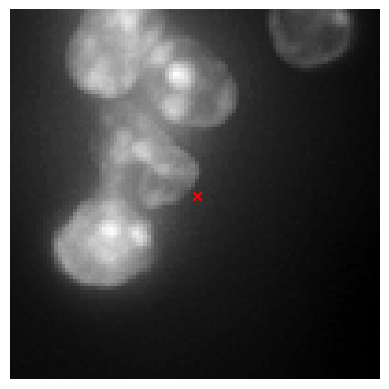

Showing image patch at (838.2166259765625, 639.9681854248047)
Patch coordinates: (3894, 2961) to (3994, 3061)


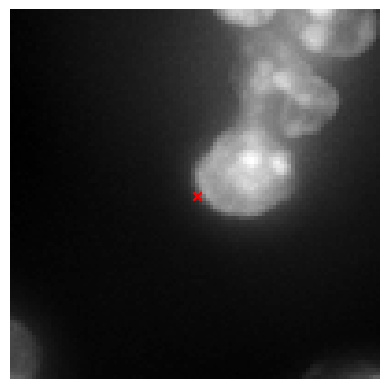

Showing image patch at (22.62326211929321, 639.1603637695313)
Patch coordinates: (56, 2957) to (156, 3057)


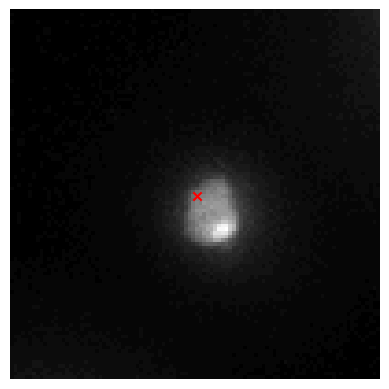

Showing image patch at (827.2270141601563, 650.5364288330078)
Patch coordinates: (3842, 3011) to (3942, 3111)


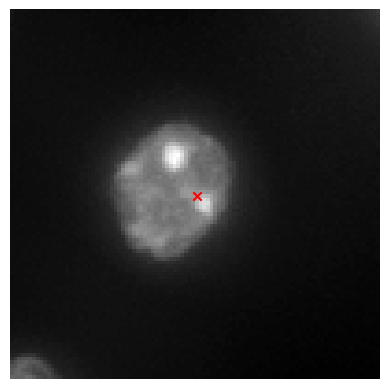

Showing image patch at (846.0655334472656, 655.6903839111328)
Patch coordinates: (3931, 3035) to (4031, 3135)


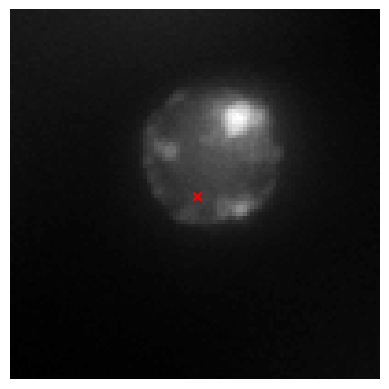

Showing image patch at (14.50281047821045, 654.7140045166016)
Patch coordinates: (18, 3031) to (118, 3131)


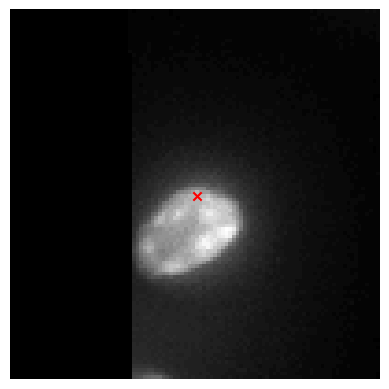

Showing image patch at (13.012401962280274, 673.1436065673828)
Patch coordinates: (11, 3117) to (111, 3217)


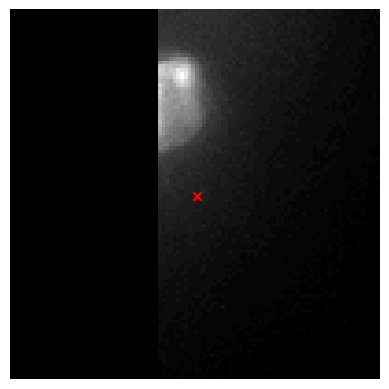

Showing image patch at (822.6635559082031, 705.2911315917969)
Patch coordinates: (3821, 3269) to (3921, 3369)


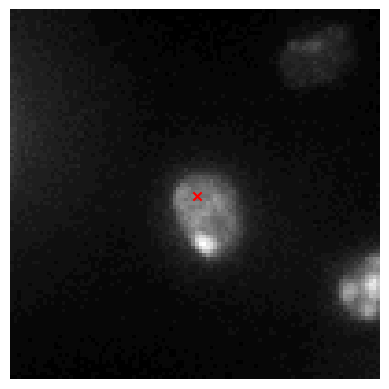

Showing image patch at (833.8449676513671, 708.3495025634766)
Patch coordinates: (3873, 3283) to (3973, 3383)


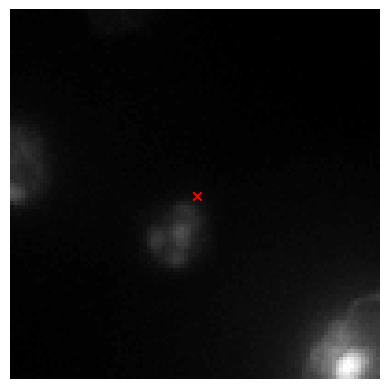

Showing image patch at (844.085693359375, 717.3221801757812)
Patch coordinates: (3922, 3325) to (4022, 3425)


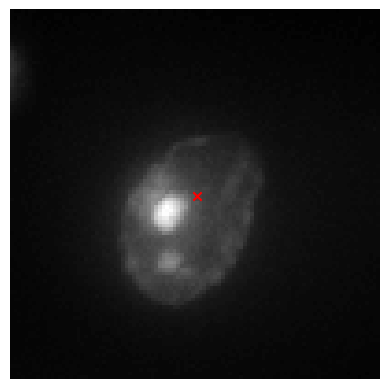

Showing image patch at (829.9765441894531, 735.637075805664)
Patch coordinates: (3855, 3411) to (3955, 3511)


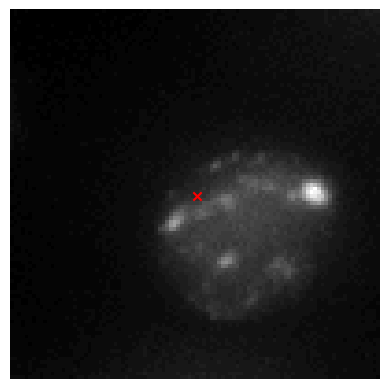

Showing image patch at (830.6844451904296, 757.8982666015625)
Patch coordinates: (3859, 3516) to (3959, 3616)


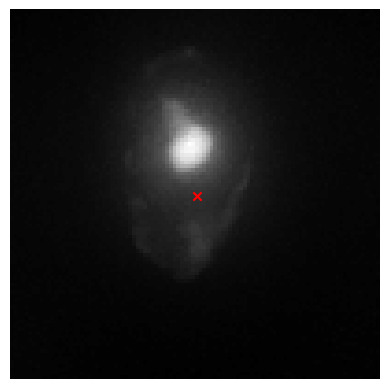

In [35]:
# show image patch around x,y pixels
import matplotlib.pyplot as plt

def show_image_patch(image, x, y, patch_size=50):
    x_min = int(max(x - patch_size // 2, 0))
    x_max = int(min(x + patch_size // 2, image.shape[1]))
    y_min = int(max(y - patch_size // 2, 0))
    y_max = int(min(y + patch_size // 2, image.shape[0]))

    print(f"Patch coordinates: ({x_min}, {y_min}) to ({x_max}, {y_max})")

    plt.imshow(image[y_min:y_max, x_min:x_max], cmap='gray')
    plt.scatter(patch_size // 2, patch_size // 2, color='red', marker='x')
    plt.axis('off')
    plt.show()

# Show image patch around the centroids
if centroids.size > 0:
    for x, y in centroids:
        print(f"Showing image patch at ({x}, {y})")
        xx = x /.2125
        yy = y /.2125
        show_image_patch(img, xx, yy, 100)

In [9]:
max_x = centroids[:, 0].max()
max_y = centroids[:, 1].max() 

print(max_x, max_y)

6656.921508789063 5276.820336914062
